In [1]:
import pandas as pd
file = "C:\\Users\\eyasf\\OneDrive\\Desktop\\projet_raies\\Data\\FX Data.xlsx"

xls = pd.ExcelFile(file)
print(xls.sheet_names)


['InterBancaire', 'BCT Fixing EUR', 'BCT Fixing USD', 'EUR-GBP-JPY vs USD']


In [2]:
#importing the data
Bct_fixing_USD = pd.read_excel(xls, "BCT Fixing USD")
Interbancaire = pd.read_excel(xls, "InterBancaire")
print(Bct_fixing_USD.head())
print(Interbancaire.head())

  Exchange Date     Bid     Ask  Mid Price
0    2020-04-10  2.9049  2.9079    2.90640
1    2020-04-13  2.8954  2.8982    2.89680
2    2020-04-14  2.8877  2.8905    2.88910
3    2020-04-15  2.8938  2.8966    2.89520
4    2020-04-16  2.8999  2.9028    2.90135
         Date     DZD     SAR     CAD      DKK     USD    GBP      JPY  \
0  2004-01-01  0.1781  3.3988  0.9138  20.5241  1.2741  2.257  11.2003   
1  2004-01-02  0.1781  3.3988  0.9138  20.5241  1.2741  2.257  11.2003   
2  2004-01-03  0.1781  3.3988  0.9138  20.5241  1.2741  2.257  11.2003   
3  2004-01-04  0.1781  3.3988  0.9138  20.5241  1.2741  2.257  11.2003   
4  2004-01-05  0.1781  3.3988  0.9138  20.5241  1.2741  2.257  11.2003   

      MAD      NOK  ...     CHF     KWD     AED     EUR  Unnamed: 15  \
0  1.3957  18.4491  ...  9.9535  4.3237  3.4717  1.5271          NaN   
1  1.3957  18.4491  ...  9.9535  4.3237  3.4717  1.5271          NaN   
2  1.3957  18.4491  ...  9.9535  4.3237  3.4717  1.5271          NaN   
3  1.3957

In [3]:
# cleaning the interbank 
IB = Interbancaire[["Date", "USD"]]
IB = IB.rename(columns={"USD": "USD_IB"})
IB['Date'] = pd.to_datetime(IB['Date'])
IB.head()


,Date,USD_IB
0,2004-01-01,1.2741
1,2004-01-02,1.2741
2,2004-01-03,1.2741
3,2004-01-04,1.2741
4,2004-01-05,1.2741


In [4]:
# clean fixing 
Fix = Bct_fixing_USD[['Exchange Date','Mid Price']]
Fix.columns = ['Date','Fixing_USD']
Fix['Date'] = pd.to_datetime(Fix['Date'])
Fix.head()


C:\Users\eyasf\AppData\Local\Temp\ipykernel_26048\913866407.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Fix['Date'] = pd.to_datetime(Fix['Date'])


,Date,Fixing_USD
0,2020-04-10,2.90640
1,2020-04-13,2.89680
2,2020-04-14,2.88910
3,2020-04-15,2.89520
4,2020-04-16,2.90135


In [5]:
IB = IB[IB['Date'] >= Fix['Date'].min()]
IB.head()

,Date,USD_IB
5944,2020-04-10,2.9107
5945,2020-04-11,2.9107
5946,2020-04-12,2.9107
5947,2020-04-13,2.8924
5948,2020-04-14,2.8894


In [6]:
#merge the two datasets
df = pd.merge(IB, Fix, on='Date', how='inner')
df.head()

,Date,USD_IB,Fixing_USD
0,2020-04-10,2.9107,2.90640
1,2020-04-13,2.8924,2.89680
2,2020-04-14,2.8894,2.88910
3,2020-04-15,2.8874,2.89520
4,2020-04-16,2.9006,2.90135


In [7]:
df['Fixing_lag'] = df['Fixing_USD'].shift(1)
df.head()

,Date,USD_IB,Fixing_USD,Fixing_lag
0,2020-04-10,2.9107,2.90640,NaN
1,2020-04-13,2.8924,2.89680,2.9064
2,2020-04-14,2.8894,2.88910,2.8968
3,2020-04-15,2.8874,2.89520,2.8891
4,2020-04-16,2.9006,2.90135,2.8952


In [8]:
#spread
df['Spread_same'] = df['USD_IB'] - df['Fixing_USD']
df['Spread_lag'] = df['USD_IB'] - df['Fixing_lag']
df.head()

,Date,USD_IB,Fixing_USD,Fixing_lag,Spread_same,Spread_lag
0,2020-04-10,2.9107,2.90640,NaN,0.00430,NaN
1,2020-04-13,2.8924,2.89680,2.9064,-0.00440,-0.0140
2,2020-04-14,2.8894,2.88910,2.8968,0.00030,-0.0074
3,2020-04-15,2.8874,2.89520,2.8891,-0.00780,-0.0017
4,2020-04-16,2.9006,2.90135,2.8952,-0.00075,0.0054


In [9]:
df = df.dropna()

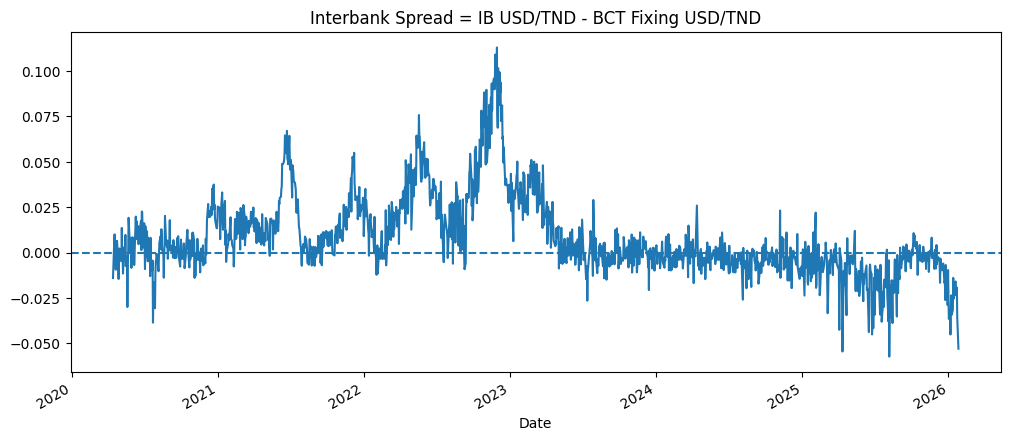

In [10]:
# Visualization 
import matplotlib.pyplot as plt
df.set_index('Date')['Spread_lag'].plot(figsize=(12,5))
plt.title("Interbank Spread = IB USD/TND - BCT Fixing USD/TND")
plt.axhline(0, linestyle='--')
plt.show()


In [11]:
#interpretation doc

In [12]:
# description 
spread_stats = df['Spread_lag'].describe()
skewness = df['Spread_lag'].skew()
kurtosis = df['Spread_lag'].kurt()

print(spread_stats)
print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

count    1460.000000
mean        0.008454
std         0.022065
min        -0.057250
25%        -0.004500
50%         0.002400
75%         0.018425
max         0.113000
Name: Spread_lag, dtype: float64
Skewness: 1.239707814402021
Kurtosis: 2.657810984240706


In [13]:
#ADF 
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(df['Spread_lag'])
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
print("Critical Values:", adf_result[4])

ADF Statistic: -2.725892878324092
p-value: 0.06966384000979045
Critical Values: {'1%': np.float64(-3.4348772553489617), '5%': np.float64(-2.8635394783531085), '10%': np.float64(-2.5678345067434516)}


In [14]:
# stationnaire mais avec p value 10 %

In [15]:
from statsmodels.tsa.stattools import kpss
stat, p_value, lags, crit = kpss(df['Spread_lag'], regression='c')
print(f"KPSS stat: {stat:.4f}, p-value: {p_value:.4f}")

KPSS stat: 1.7818, p-value: 0.0100


C:\Users\eyasf\AppData\Local\Temp\ipykernel_26048\2866380103.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p_value, lags, crit = kpss(df['Spread_lag'], regression='c')


In [16]:
#interpretation : “Despite mixed stationarity test results, we do not difference the spread as it exhibits mean-reverting behavior and retains clear economic interpretation in levels.”

In [17]:
#interpretation : Si le spread est élevé aujourd’hui, que va-t-il se passer demain ?”
import statsmodels.api as sm

df['Spread_lag1'] = df['Spread_lag'].shift(1)
df_ar = df.dropna()

X = sm.add_constant(df_ar['Spread_lag1'])
y = df_ar['Spread_lag']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Spread_lag   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                     4605.
Date:                Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                        20:52:52   Log-Likelihood:                 4534.6
No. Observations:                1459   AIC:                            -9065.
Df Residuals:                    1457   BIC:                            -9055.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0010      0.000      3.449      

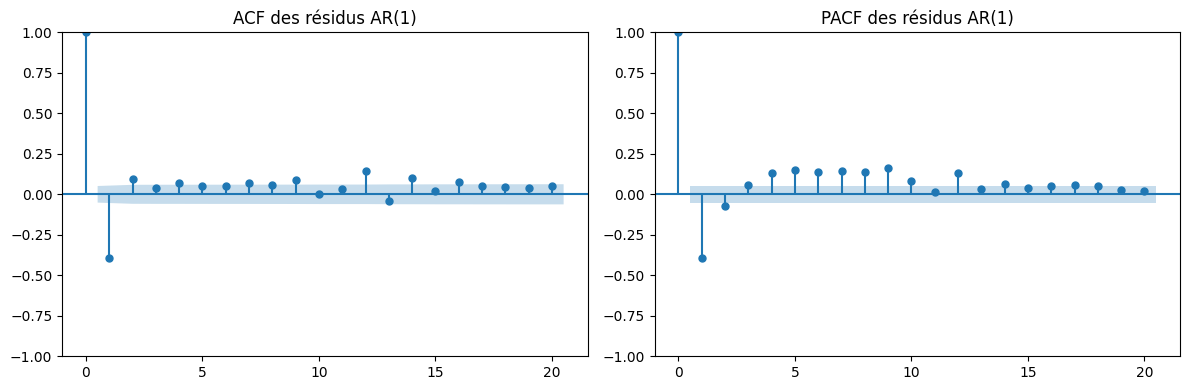

Durbin-Watson: 2.7792


In [18]:
# Residual analysis
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson

# Résidus du modèle
residuals = model.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(residuals,  lags=20, ax=axes[0], title="ACF des résidus AR(1)")
plot_pacf(residuals, lags=20, ax=axes[1], title="PACF des résidus AR(1)")
plt.tight_layout()
plt.savefig("ar1_residual_diagnostics.png", dpi=150)
plt.show()

# Durbin-Watson
dw = durbin_watson(residuals)
print(f"Durbin-Watson: {dw:.4f}")
# Proche de 2 = pas d'autocorrélation résiduelle → AR(2) est suffisant

In [19]:
# AR(2)
df['Spread_lag2'] = df['Spread_lag'].shift(2)
df_ar2=df.dropna()
X= sm.add_constant(df_ar2[['Spread_lag1','Spread_lag2']])
y = df_ar2['Spread_lag']
model2 = sm.OLS(y,X).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:             Spread_lag   R-squared:                       0.808
Model:                            OLS   Adj. R-squared:                  0.808
Method:                 Least Squares   F-statistic:                     3063.
Date:                Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                        20:52:53   Log-Likelihood:                 4695.2
No. Observations:                1458   AIC:                            -9384.
Df Residuals:                    1455   BIC:                            -9369.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0005      0.000      1.979      

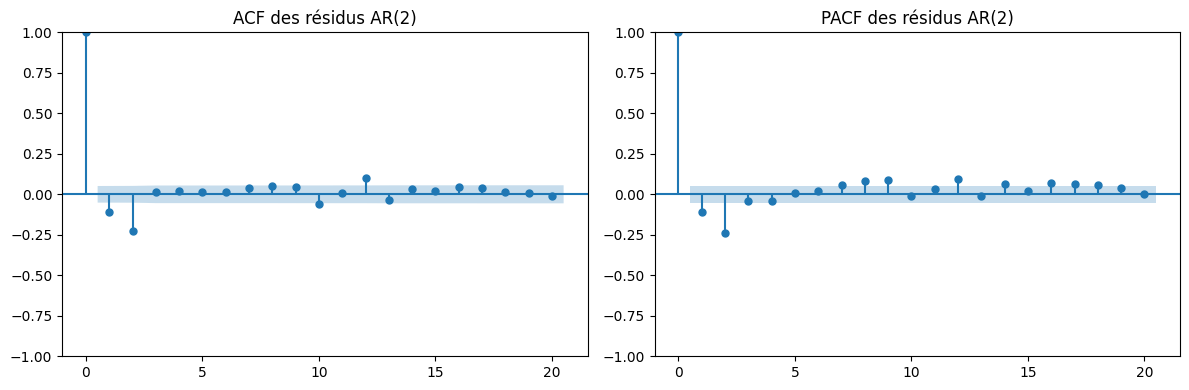

Durbin-Watson: 2.2109


In [20]:
# Residual analysis
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson

# Résidus du modèle
residuals = model2.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(residuals,  lags=20, ax=axes[0], title="ACF des résidus AR(2)")
plot_pacf(residuals, lags=20, ax=axes[1], title="PACF des résidus AR(2)")
plt.tight_layout()
plt.savefig("ar2_residual_diagnostics.png", dpi=150)
plt.show()

# Durbin-Watson
dw = durbin_watson(residuals)
print(f"Durbin-Watson: {dw:.4f}")
# Proche de 2 = pas d'autocorrélation résiduelle → AR(2) est suffisant

In [21]:
#AR(3)
df['Spread_lag3'] = df['Spread_lag'].shift(3)
df_ar3=df.dropna()
X= sm.add_constant(df_ar3[['Spread_lag1','Spread_lag2','Spread_lag3']])
y = df_ar3['Spread_lag']
model3 = sm.OLS(y,X).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:             Spread_lag   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     2196.
Date:                Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                        20:52:54   Log-Likelihood:                 4735.6
No. Observations:                1457   AIC:                            -9463.
Df Residuals:                    1453   BIC:                            -9442.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0004      0.000      1.439      

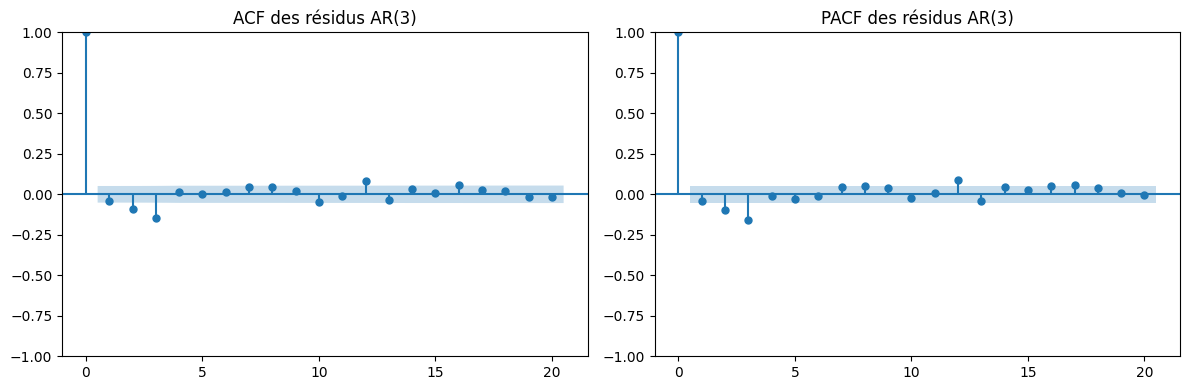

Durbin-Watson: 2.0738


In [22]:
#residual analysis
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson

# Résidus du modèle
residuals = model3.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(residuals,  lags=20, ax=axes[0], title="ACF des résidus AR(3)")
plot_pacf(residuals, lags=20, ax=axes[1], title="PACF des résidus AR(3)")
plt.tight_layout()
plt.savefig("ar3_residual_diagnostics.png", dpi=150)
plt.show()

# Durbin-Watson
dw = durbin_watson(residuals)
print(f"Durbin-Watson: {dw:.4f}")
# Proche de 2 = pas d'autocorrélation résiduelle → AR(3) est suffisant

In [23]:
df['Spread_lag4'] = df['Spread_lag'].shift(4)
df_ar4=df.dropna()
X= sm.add_constant(df_ar4[['Spread_lag1','Spread_lag2','Spread_lag3','Spread_lag4']])
y = df_ar4['Spread_lag']
model4 = sm.OLS(y,X).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:             Spread_lag   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     1703.
Date:                Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                        20:52:56   Log-Likelihood:                 4752.7
No. Observations:                1456   AIC:                            -9495.
Df Residuals:                    1451   BIC:                            -9469.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0003      0.000      1.111      

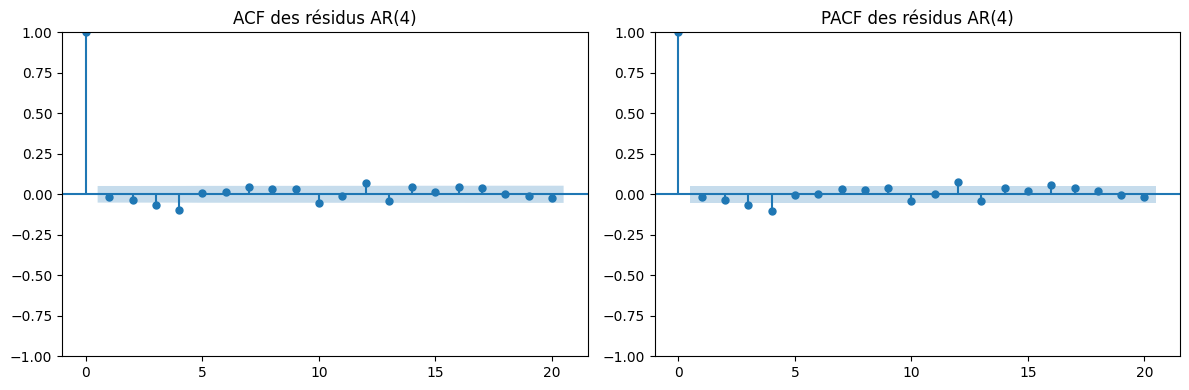

Durbin-Watson: 2.0285


In [24]:
# Residual analysis
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson

# Résidus du modèle
residuals = model4.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(residuals,  lags=20, ax=axes[0], title="ACF des résidus AR(4)")
plot_pacf(residuals, lags=20, ax=axes[1], title="PACF des résidus AR(4)")
plt.tight_layout()
plt.savefig("ar4_residual_diagnostics.png", dpi=150)
plt.show()

# Durbin-Watson
dw = durbin_watson(residuals)
print(f"Durbin-Watson: {dw:.4f}")
# Proche de 2 = pas d'autocorrélation résiduelle → AR(4) est suffisant

In [25]:
# The AR(2) is the best model since it has a good R2 and it is interpretable

In [26]:
# Markov approach
spread = df['Spread_lag'].dropna()
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

markov_model = MarkovRegression(
    spread,
    k_regimes=2,
    trend='c',
    switching_variance=True
)

markov_result = markov_model.fit()

print(markov_result.summary())

c:\Users\eyasf\Miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:             Spread_lag   No. Observations:                 1460
Model:               MarkovRegression   Log Likelihood                4197.279
Date:                Mon, 11 May 2026   AIC                          -8382.558
Time:                        20:52:57   BIC                          -8350.840
Sample:                             0   HQIC                         -8370.726
                               - 1460                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0019      0.000     -5.483      0.000      -0.003      -0.001
sigma2       6.32e-05   5.24e-06     12.066      0.0

In [27]:
probs = markov_result.smoothed_marginal_probabilities

probs.head()

,0,1
1,0.994999,0.005001
2,0.998939,0.001061
3,0.999679,0.000321
4,0.999730,0.000270
5,0.999671,0.000329


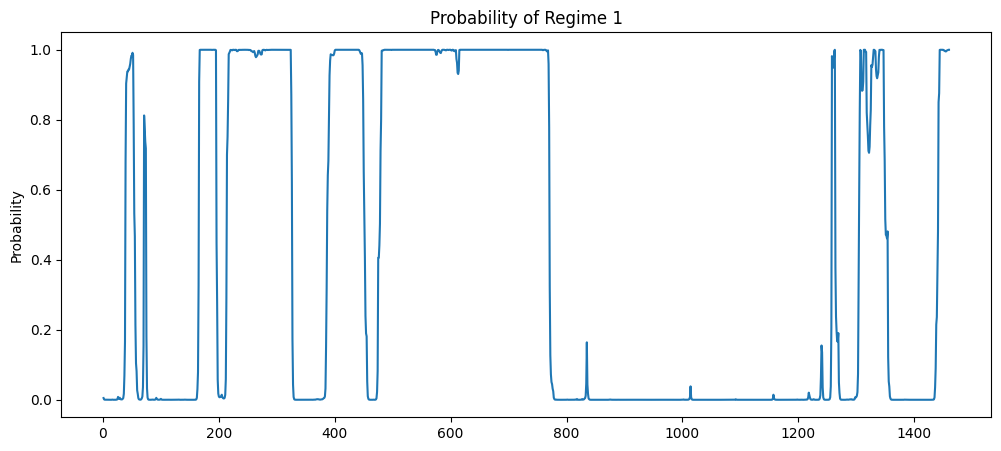

In [28]:
probs[1].plot(figsize=(12,5))
plt.title("Probability of Regime 1")
plt.ylabel("Probability")
plt.show()

In [29]:
# interpretation : The Markov model identifies two regimes in the spread data, with probabilities that fluctuate over time. The first regime is characterized by a lower mean spread and lower variance, while the second regime has a higher mean spread and higher variance. The probabilities of being in each regime change over time, indicating that the spread can switch between these two states. This suggests that there may be periods of stability (regime 1) and periods of higher volatility (regime 2) in the interbank spread, which could be influenced by various economic factors or market conditions.

In [30]:
# GARCH(1,1)
from arch import arch_model

spread = df['Spread_lag'].dropna()

garch = arch_model(
    spread,
    vol='Garch',
    p=1,
    q=1,
    mean='Constant'
)

garch_result = garch.fit()
sigma_series = garch_result.conditional_volatility
latest_sigma = sigma_series.iloc[-1]
print(garch_result.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 3.9878128044738525e+21
Iteration:      2,   Func. Count:     21,   Neg. LLF: 5.143991798044807e+20
Iteration:      3,   Func. Count:     34,   Neg. LLF: 54999161443209.67
Iteration:      4,   Func. Count:     49,   Neg. LLF: 2693691628149920.0
Iteration:      5,   Func. Count:     61,   Neg. LLF: 255393474958.51587
Iteration:      6,   Func. Count:     76,   Neg. LLF: 1703930287049011.0
Iteration:      7,   Func. Count:     88,   Neg. LLF: 124752951940.43443
Iteration:      8,   Func. Count:    102,   Neg. LLF: -4173.785027788814
Optimization terminated successfully    (Exit mode 0)
            Current function value: -4173.785037818475
            Iterations: 12
            Function evaluations: 102
            Gradient evaluations: 8
                     Constant Mean - GARCH Model Results                      
Dep. Variable:             Spread_lag   R-squared:                       0.000
Mean Model:             Constant Mean   Ad

c:\Users\eyasf\Miniconda3\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0004865. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [31]:
# interpretation : Found: α + β ≈ 0.98 → very persistent volatility 
#Volatility clusters during stress
#Risk is time-varying

In [32]:
df.to_csv("Output_data_workstreamB.csv", index=False)

In [33]:
returns = pd.read_csv(r"C:\Users\eyasf\OneDrive\Desktop\projet_raies\Data\Output_data_workstreamA.csv")

In [34]:
returns.head()

,Date,USD_TND,EURUSD,GBPUSD,USDJPY,r_USD_TND,r_EURUSD,r_GBPUSD,r_USDJPY
0,2020-04-13,2.89680,1.0913,1.2507,107.76,-0.003309,-0.002014,0.004407,-0.006475
1,2020-04-14,2.88910,1.0979,1.2623,107.20,-0.002662,0.006030,0.009232,-0.005210
2,2020-04-15,2.89520,1.0907,1.2514,107.47,0.002109,-0.006580,-0.008673,0.002515
3,2020-04-16,2.90135,1.0835,1.2455,107.94,0.002122,-0.006623,-0.004726,0.004364
4,2020-04-17,2.90870,1.0876,1.2499,107.51,0.002530,0.003777,0.003526,-0.003992


In [35]:
#Workstream C
# New data for workstream C
data1 = df.dropna(subset=["Spread_lag"]).copy()
data1 = data1.sort_values("Date").reset_index(drop=True)

data1["spread"] = data1["Spread_lag"]
data1.head()

,Date,USD_IB,Fixing_USD,Fixing_lag,Spread_same,Spread_lag,Spread_lag1,Spread_lag2,Spread_lag3,Spread_lag4,spread
0,2020-04-13,2.8924,2.89680,2.90640,-0.00440,-0.01400,NaN,NaN,NaN,NaN,-0.01400
1,2020-04-14,2.8894,2.88910,2.89680,0.00030,-0.00740,-0.0140,NaN,NaN,NaN,-0.00740
2,2020-04-15,2.8874,2.89520,2.88910,-0.00780,-0.00170,-0.0074,-0.0140,NaN,NaN,-0.00170
3,2020-04-16,2.9006,2.90135,2.89520,-0.00075,0.00540,-0.0017,-0.0074,-0.0140,NaN,0.00540
4,2020-04-17,2.9114,2.90870,2.90135,0.00270,0.01005,0.0054,-0.0017,-0.0074,-0.014,0.01005


In [36]:
data1.drop(columns=["Spread_same", "Spread_lag", "Spread_lag1", "Spread_lag2", "Spread_lag3", "Spread_lag4"], inplace=True, errors="ignore")
data1.head()

,Date,USD_IB,Fixing_USD,Fixing_lag,spread
0,2020-04-13,2.8924,2.89680,2.90640,-0.01400
1,2020-04-14,2.8894,2.88910,2.89680,-0.00740
2,2020-04-15,2.8874,2.89520,2.88910,-0.00170
3,2020-04-16,2.9006,2.90135,2.89520,0.00540
4,2020-04-17,2.9114,2.90870,2.90135,0.01005


In [37]:
# Add Markov regime probabilities to the dataset
import numpy as np
probs_clean = probs.reset_index(drop=True)

data1 = data1.iloc[-len(probs_clean):].copy().reset_index(drop=True)

data1["P_regime_0"] = probs_clean[0]
data1["P_regime_1"] = probs_clean[1]

data1["regime"] = np.where(data1["P_regime_1"] > data1["P_regime_0"], 1, 0)

data1.head()

,Date,USD_IB,Fixing_USD,Fixing_lag,spread,P_regime_0,P_regime_1,regime
0,2020-04-13,2.8924,2.89680,2.90640,-0.01400,0.994999,0.005001,0
1,2020-04-14,2.8894,2.88910,2.89680,-0.00740,0.998939,0.001061,0
2,2020-04-15,2.8874,2.89520,2.88910,-0.00170,0.999679,0.000321,0
3,2020-04-16,2.9006,2.90135,2.89520,0.00540,0.999730,0.000270,0
4,2020-04-17,2.9114,2.90870,2.90135,0.01005,0.999671,0.000329,0


In [38]:
# Understand the regimes 
regime_stats = data1.groupby("regime")["spread"].agg(["mean", "std", "count"])
print(regime_stats)

stable_regime = regime_stats["std"].idxmin()
stress_regime = regime_stats["std"].idxmax()

print("Stable regime:", stable_regime)
print("Stress regime:", stress_regime)

            mean       std  count
regime                           
0      -0.001939  0.007951    868
1       0.023691  0.026796    592
Stable regime: 0
Stress regime: 1


In [39]:
#The latest fixing and FX returns are extracted to compute the real-time intrinsic value of USD/TND based on current market movements.
returns = returns.copy()
returns["Date"] = df["Date"].iloc[-len(returns):].values
returns = returns.set_index("Date")
latest_date = df["Date"].iloc[-1]
latest_fixing = df["Fixing_USD"].iloc[-1]

latest_returns = returns.loc[latest_date]

latest_r_EURUSD = latest_returns["r_EURUSD"]
latest_r_GBPUSD = latest_returns["r_GBPUSD"]
latest_r_USDJPY = latest_returns["r_USDJPY"]


In [40]:
#Create a copy from date1 to test 
eval_df= data1.copy()

In [41]:
#split the dataset
split = split = int(len(eval_df) * 0.8)

train = eval_df.iloc[:split].copy()
test = eval_df.iloc[split:].copy()

In [42]:
# step 1: Construct two different models AR(2) for each regim
from statsmodels.tsa.ar_model import AutoReg

stable_train = train[train["regime"] == stable_regime]["spread"]
stress_train = train[train["regime"] == stress_regime]["spread"]

ar_stable = AutoReg(stable_train, lags=2, old_names=False).fit()
ar_stress = AutoReg(stress_train, lags=2, old_names=False).fit()

c:\Users\eyasf\Miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\eyasf\Miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [43]:
import numpy as np

# STORAGE
preds = []
actuals = []
dates = []
sigmas = []

# KALMAN INIT
R = train["spread"].var()        
x_hat = train["spread"].iloc[-1]  
P = R                              

history = train["spread"].tolist()


# =========================
# LOOP ON TEST DATA
# =========================
for i in range(len(test)):

    row = test.iloc[i]

    # -------------------------
    # 1. Regime-dependent Q
    # -------------------------
    if row["regime"] == stress_regime:
        Q = (latest_sigma ** 2) * 10
    else:
        Q = (latest_sigma ** 2) * 2

    # -------------------------
    # 2. Markov probabilities
    # -------------------------
    p_stable = row[f"P_regime_{stable_regime}"]
    p_stress = row[f"P_regime_{stress_regime}"]

    # -------------------------
    # 3. AR(2) dynamic forecast
    # -------------------------
    last1 = history[-1]   # spread t-1
    last2 = history[-2]   # spread t-2

    stable_forecast = (
        ar_stable.params["const"]
        + ar_stable.params["spread.L1"] * last1
        + ar_stable.params["spread.L2"] * last2
    )

    stress_forecast = (
        ar_stress.params["const"]
        + ar_stress.params["spread.L1"] * last1
        + ar_stress.params["spread.L2"] * last2
    )

    # -------------------------
    # 4. Markov-weighted prediction
    # -------------------------
    method2_pred = (
        p_stable * stable_forecast
        + p_stress * stress_forecast
    )

    # -------------------------
    # 5. Kalman update
    # -------------------------
    y_t = row["spread"]   # real observed spread during backtest

    P_pred = P + Q
    K = P_pred / (P_pred + R)

    x_hat = method2_pred + K * (y_t - method2_pred)
    P = (1 - K) * P_pred

    kalman_pred = x_hat
    kalman_sigma = np.sqrt(P)

    # -------------------------
    # 6. Store results
    # -------------------------
    preds.append(kalman_pred)
    actuals.append(y_t)
    dates.append(row["Date"])
    sigmas.append(kalman_sigma)

    # -------------------------
    # 7. Update history
    # -------------------------
    history.append(y_t)

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(actuals, preds)
rmse = np.sqrt(mean_squared_error(actuals, preds))

print("Nowcasting MAE:", mae)
print("Nowcasting RMSE:", rmse)

Nowcasting MAE: 0.0012975817388812417
Nowcasting RMSE: 0.00179624768541372


In [45]:
#interpretation :
#MAE = 0.00130
#On average, your nowcasted spread is wrong by about 0.0013 TND.
#RMSE = 0.00180
#The typical prediction error is about 0.0018 TND.
#Since RMSE is close to MAE, your model does not seem to have huge extreme errors.

In [46]:
#naive bayes 
naive_pred = test["spread"].shift(1).dropna()
naive_actual = test["spread"].iloc[1:]

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("Naive MAE:", mean_absolute_error(naive_actual, naive_pred))
print("Naive RMSE:", np.sqrt(mean_squared_error(naive_actual, naive_pred)))

Naive MAE: 0.009662199312714772
Naive RMSE: 0.013028696189512834


In [47]:
#interpretation :
#The proposed nowcasting model significantly outperforms the naive benchmark. While the naive approach yields a MAE of 0.00966 and an RMSE of 0.01303, the hybrid Markov–AR(2)–Kalman model reduces these errors to 0.00130 and 0.00180 respectively. This represents an improvement of more than 7 times in both metrics, demonstrating the model’s ability to effectively capture regime dynamics, mean-reversion behavior, and time-varying uncertainty in the interbank spread.

In [48]:
returns = returns.reset_index()

In [49]:
returns.head()

,Date,USD_TND,EURUSD,GBPUSD,USDJPY,r_USD_TND,r_EURUSD,r_GBPUSD,r_USDJPY
0,2020-06-09,2.89680,1.0913,1.2507,107.76,-0.003309,-0.002014,0.004407,-0.006475
1,2020-06-10,2.88910,1.0979,1.2623,107.20,-0.002662,0.006030,0.009232,-0.005210
2,2020-06-11,2.89520,1.0907,1.2514,107.47,0.002109,-0.006580,-0.008673,0.002515
3,2020-06-12,2.90135,1.0835,1.2455,107.94,0.002122,-0.006623,-0.004726,0.004364
4,2020-06-15,2.90870,1.0876,1.2499,107.51,0.002530,0.003777,0.003526,-0.003992


In [50]:
# This step integrates the FX basket model with the nowcasted interbank spread.
# Create results table
results_table = pd.DataFrame({
    "Date": dates,
    "Real_spread": actuals,
    "Nowcasted_spread": preds,
    "Kalman_sigma": sigmas
})
results_table.head()

,Date,Real_spread,Nowcasted_spread,Kalman_sigma
0,2024-11-22,0.01110,0.008609,0.019147
1,2024-11-25,-0.01535,-0.011949,0.019035
2,2024-11-26,-0.00700,-0.005473,0.019030
3,2024-11-27,-0.01400,-0.011817,0.019030
4,2024-11-28,-0.00260,-0.002713,0.019030


In [51]:
# Add fixing values from test period
results_table["Fixing_USD"] = test["Fixing_USD"].values
results_table.head()

,Date,Real_spread,Nowcasted_spread,Kalman_sigma,Fixing_USD
0,2024-11-22,0.01110,0.008609,0.019147,3.18745
1,2024-11-25,-0.01535,-0.011949,0.019035,3.16940
2,2024-11-26,-0.00700,-0.005473,0.019030,3.17230
3,2024-11-27,-0.01400,-0.011817,0.019030,3.15940
4,2024-11-28,-0.00260,-0.002713,0.019030,3.16295


In [52]:

# OLS basket weights from Workstream A
w_EUR = -0.3654
w_GBP = -0.0318
w_JPY = 0.0496

# Prepare returns for test period
returns_for_test = returns.copy()

# If returns does not have Date as index, attach dates
if "Date" not in returns_for_test.columns:
    returns_for_test["Date"] = df["Date"].iloc[-len(returns_for_test):].values

returns_for_test["Date"] = pd.to_datetime(returns_for_test["Date"])

# Add FX returns to results table
results_table = results_table.merge(
    returns_for_test[["Date", "r_EURUSD", "r_GBPUSD", "r_USDJPY"]],
    on="Date",
    how="left"
)

In [53]:

# Basket movement
results_table["basket_change"] = (
    w_EUR * results_table["r_EURUSD"]
    + w_GBP * results_table["r_GBPUSD"]
    + w_JPY * results_table["r_USDJPY"]
)

# Basket value = fixing × (1 + basket movement)

results_table["Basket_value"] = (
    results_table["Fixing_USD"] * np.exp(results_table["basket_change"])
)

In [54]:

# Nowcasted intrinsic value
results_table["Nowcasted_intrinsic"] = (
    results_table["Basket_value"] + results_table["Nowcasted_spread"]
)

# Real value = actual interbank value
results_table["Real_value"] = test["USD_IB"].values

# Error
results_table["Error"] = (
    results_table["Real_value"] - results_table["Nowcasted_intrinsic"]
)

# Intrinsic bands using Kalman sigma
results_table["Lower_intrinsic_band"] = (
    results_table["Nowcasted_intrinsic"] - 1.96 * results_table["Kalman_sigma"]
)

results_table["Upper_intrinsic_band"] = (
    results_table["Nowcasted_intrinsic"] + 1.96 * results_table["Kalman_sigma"]
)

# Final clean table
final_table = results_table[[
    "Date",
    "Real_value",
    "Nowcasted_intrinsic",
    "Error",
    "Lower_intrinsic_band",
    "Upper_intrinsic_band"
]]

final_table.tail()

,Date,Real_value,Nowcasted_intrinsic,Error,Lower_intrinsic_band,Upper_intrinsic_band
287,2026-01-20,2.9072,2.883431,0.023769,2.842622,2.924239
288,2026-01-21,2.8883,2.894030,-0.005730,2.853222,2.934839
289,2026-01-22,2.8942,2.890806,0.003394,2.849998,2.931615
290,2026-01-23,2.8807,2.860696,0.020004,2.819887,2.901504
291,2026-01-26,2.8587,2.818295,0.040405,2.777487,2.859104


In [55]:
# Vérification 1
print((results_table["Date"].reset_index(drop=True) == test["Date"].reset_index(drop=True)).all())
# Vérification 2 : no holes
print(results_table.isna().sum())
# Vérification 3 : merge correct
print(results_table[["Date", "r_EURUSD"]].head())

True
Date                    0
Real_spread             0
Nowcasted_spread        0
Kalman_sigma            0
Fixing_USD              0
r_EURUSD                0
r_GBPUSD                0
r_USDJPY                0
basket_change           0
Basket_value            0
Nowcasted_intrinsic     0
Real_value              0
Error                   0
Lower_intrinsic_band    0
Upper_intrinsic_band    0
dtype: int64
        Date  r_EURUSD
0 2024-11-22 -0.001164
1 2024-11-25 -0.002601
2 2024-11-26 -0.006036
3 2024-11-27 -0.001990
4 2024-11-28 -0.001268


In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_intrinsic = mean_absolute_error(
    final_table["Real_value"],
    final_table["Nowcasted_intrinsic"]
)

rmse_intrinsic = np.sqrt(mean_squared_error(
    final_table["Real_value"],
    final_table["Nowcasted_intrinsic"]
))

print("Intrinsic MAE:", mae_intrinsic)
print("Intrinsic RMSE:", rmse_intrinsic)

Intrinsic MAE: 0.007981355611525163
Intrinsic RMSE: 0.011267446153896132


In [57]:
# coverage  :  verify if the value is in the range 
inside = (
    (final_table["Real_value"] >= final_table["Lower_intrinsic_band"]) &
    (final_table["Real_value"] <= final_table["Upper_intrinsic_band"])
)

print("Coverage:", inside.mean())



Coverage: 0.9897260273972602


In [58]:
#Almost 99% of the observed interbank rates fall within the model’s confidence interval.

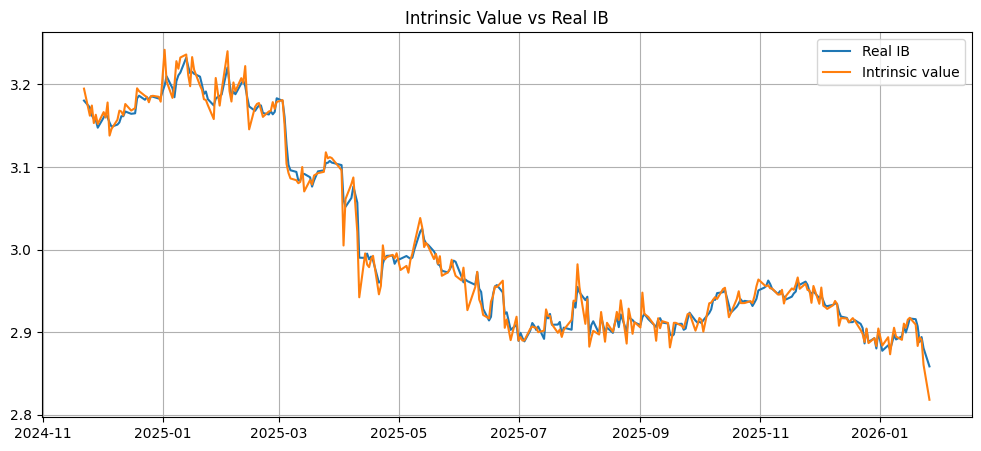

In [59]:
# Intrinsic value vs real IB
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(final_table["Date"], final_table["Real_value"], label="Real IB")
plt.plot(final_table["Date"], final_table["Nowcasted_intrinsic"], label="Intrinsic value")

plt.legend()
plt.title("Intrinsic Value vs Real IB")
plt.grid(True)
plt.show()

In [60]:
# plot errors over time 
final_table.to_csv("nowcasting_results_table.csv", index=False)


C:\Users\eyasf\AppData\Local\Temp\ipykernel_26048\932659078.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_table["Abs_Error"] = final_table["Error"].abs()


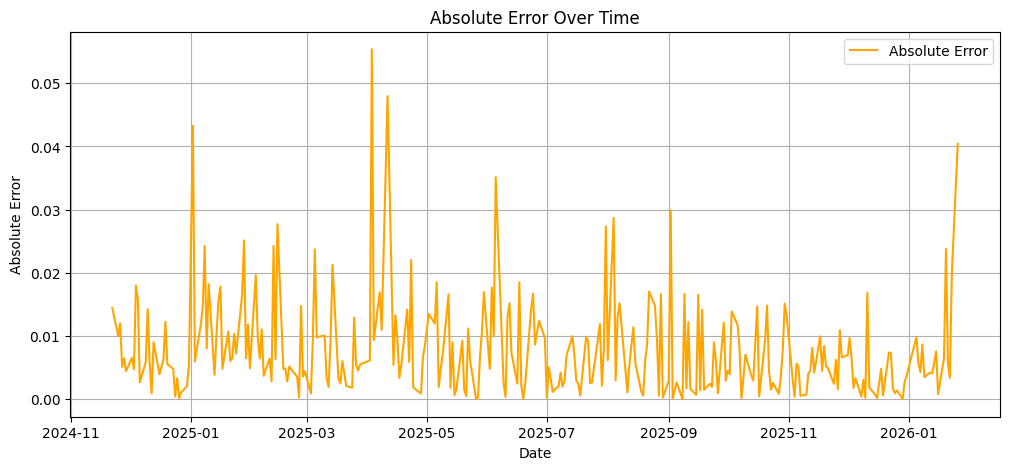

In [61]:
final_table["Abs_Error"] = final_table["Error"].abs()

plt.figure(figsize=(12,5))

plt.plot(final_table["Date"], final_table["Abs_Error"], label="Absolute Error", color="orange")

plt.title("Absolute Error Over Time")
plt.xlabel("Date")
plt.ylabel("Absolute Error")
plt.legend()
plt.grid(True)

plt.show()

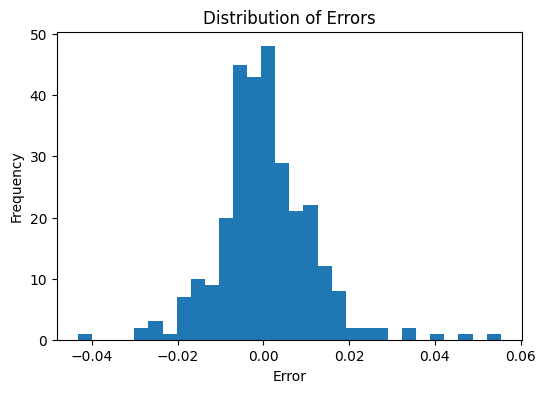

In [62]:
# error distribution
plt.figure(figsize=(6,4))

plt.hist(final_table["Error"], bins=30)

plt.title("Distribution of Errors")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.show()

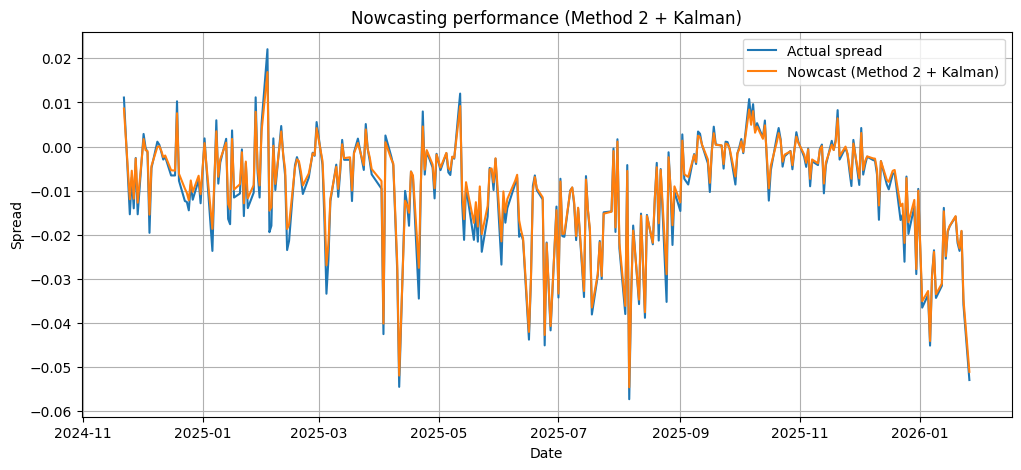

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(dates, actuals, label="Actual spread")
plt.plot(dates, preds, label="Nowcast (Method 2 + Kalman)")

plt.legend()
plt.title("Nowcasting performance (Method 2 + Kalman)")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.grid(True)
plt.show()

In [64]:
# Approach 2 : Xgboost 
# ==============================
# 1. Create ML dataframe
# ==============================

df_ml = data1.copy()
df_ml["Date"] = pd.to_datetime(df_ml["Date"])
df_ml = df_ml.sort_values("Date").reset_index(drop=True)

# Target
df_ml["target"] = df_ml["spread"]

# Lag features
df_ml["lag1"] = df_ml["spread"].shift(1)
df_ml["lag2"] = df_ml["spread"].shift(2)

# Rolling features
df_ml["roll_mean_5"] = df_ml["spread"].shift(1).rolling(5).mean()
df_ml["roll_std_5"] = df_ml["spread"].shift(1).rolling(5).std()

# Calendar features
df_ml["day_of_week"] = df_ml["Date"].dt.dayofweek
df_ml["month"] = df_ml["Date"].dt.month
df_ml["is_month_end"] = df_ml["Date"].dt.is_month_end.astype(int)

In [65]:
# ==============================
# 2. Add FX returns if needed
# ==============================

returns["Date"] = pd.to_datetime(returns["Date"])

df_ml = df_ml.merge(
    returns[["Date", "r_EURUSD", "r_GBPUSD", "r_USDJPY"]],
    on="Date",
    how="left"
)

In [66]:
# ==============================
# 3. Select features and clean
# ==============================

features = [
    "lag1",
    "lag2",
    "roll_mean_5",
    "roll_std_5",
    "day_of_week",
    "month",
    "is_month_end",
    "r_EURUSD",
    "r_GBPUSD",
    "r_USDJPY"
]

df_ml = df_ml.dropna(subset=features + ["target"]).reset_index(drop=True)

X = df_ml[features]
y = df_ml["target"]

In [67]:
# ==============================
# 4. Time-series train/test split
# ==============================

split = int(len(df_ml) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

dates_test = df_ml["Date"].iloc[split:]

In [68]:
from xgboost import XGBRegressor

# ==============================
# 5. Train XGBoost
# ==============================

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [69]:
# ==============================
# 6. Predict and evaluate
# ==============================

xgb_preds = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, xgb_preds)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_preds))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

XGBoost MAE: 0.008946649058176246
XGBoost RMSE: 0.012750434867390054


In [70]:
# ==============================
# Build intrinsic value using XGBoost predictions
# ==============================

# OLS basket weights from Workstream A
w_EUR = -0.3654
w_GBP = -0.0318
w_JPY = 0.0496

# Create evaluation dataframe aligned with XGBoost test period
xgb_intrinsic = df_ml.iloc[split:].copy().reset_index(drop=True)

# Add XGBoost predicted spread
xgb_intrinsic["XGBoost_spread"] = xgb_preds

# Compute basket movement using FX returns
xgb_intrinsic["basket_change"] = (
    w_EUR * xgb_intrinsic["r_EURUSD"]
    + w_GBP * xgb_intrinsic["r_GBPUSD"]
    + w_JPY * xgb_intrinsic["r_USDJPY"]
)

# Compute basket value
xgb_intrinsic["Basket_value"] = (
    xgb_intrinsic["Fixing_USD"] * (1 + xgb_intrinsic["basket_change"])
)

# Compute intrinsic value
xgb_intrinsic["XGBoost_intrinsic"] = (
    xgb_intrinsic["Basket_value"] + xgb_intrinsic["XGBoost_spread"]
)

# Real interbank value
xgb_intrinsic["Real_value"] = xgb_intrinsic["USD_IB"]

# Compute error
xgb_intrinsic["Error"] = (
    xgb_intrinsic["Real_value"] - xgb_intrinsic["XGBoost_intrinsic"]
)

In [71]:
# ==============================
# Compute MAE and RMSE for intrinsic value
# ==============================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_xgb_intrinsic = mean_absolute_error(
    xgb_intrinsic["Real_value"],
    xgb_intrinsic["XGBoost_intrinsic"]
)

rmse_xgb_intrinsic = np.sqrt(mean_squared_error(
    xgb_intrinsic["Real_value"],
    xgb_intrinsic["XGBoost_intrinsic"]
))

print("XGBoost Intrinsic MAE:", mae_xgb_intrinsic)
print("XGBoost Intrinsic RMSE:", rmse_xgb_intrinsic)

XGBoost Intrinsic MAE: 0.008423483102108192
XGBoost Intrinsic RMSE: 0.01158237121005176


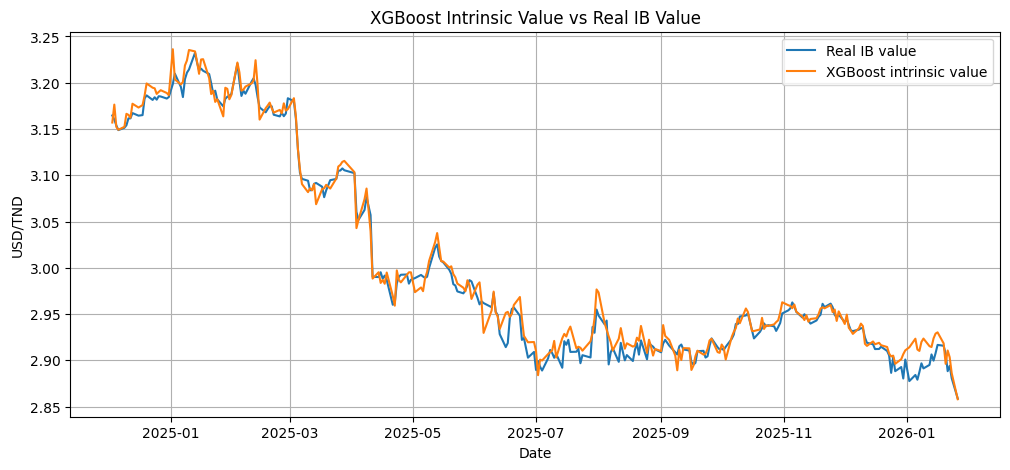

In [72]:
# ==============================
# Plot intrinsic value vs real IB value
# ==============================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    xgb_intrinsic["Date"],
    xgb_intrinsic["Real_value"],
    label="Real IB value"
)

plt.plot(
    xgb_intrinsic["Date"],
    xgb_intrinsic["XGBoost_intrinsic"],
    label="XGBoost intrinsic value"
)

plt.title("XGBoost Intrinsic Value vs Real IB Value")
plt.xlabel("Date")
plt.ylabel("USD/TND")
plt.legend()
plt.grid(True)

plt.show()

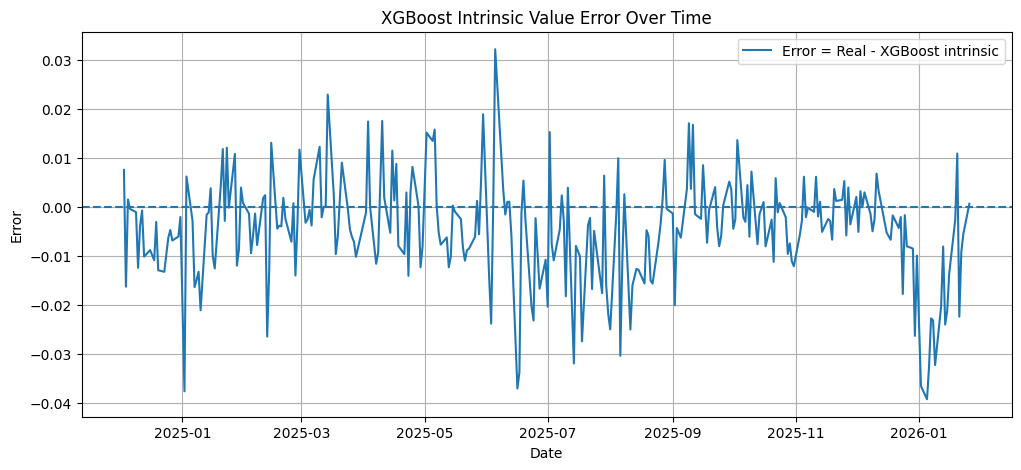

In [73]:

# ==============================
# Plot error over time of the intrinsic value
# ==============================

plt.figure(figsize=(12,5))

plt.plot(
    xgb_intrinsic["Date"],
    xgb_intrinsic["Error"],
    label="Error = Real - XGBoost intrinsic"
)

plt.axhline(0, linestyle="--")

plt.title("XGBoost Intrinsic Value Error Over Time")
plt.xlabel("Date")
plt.ylabel("Error")
plt.legend()
plt.grid(True)

plt.show()

In [74]:
# ==============================
# 7. Create results table of the spread nowcasting
# ==============================

xgb_results = pd.DataFrame({
    "Date": dates_test.values,
    "Actual_spread": y_test.values,
    "XGBoost_nowcast": xgb_preds
})

xgb_results["Error"] = xgb_results["Actual_spread"] - xgb_results["XGBoost_nowcast"]
xgb_results["Abs_Error"] = xgb_results["Error"].abs()

xgb_results.tail()

,Date,Actual_spread,XGBoost_nowcast,Error,Abs_Error
280,2026-01-20,-0.02185,-0.008424,-0.013426,0.013426
281,2026-01-21,-0.02365,-0.006449,-0.017201,0.017201
282,2026-01-22,-0.01920,-0.006551,-0.012649,0.012649
283,2026-01-23,-0.03590,-0.009134,-0.026766,0.026766
284,2026-01-26,-0.05290,-0.011278,-0.041622,0.041622


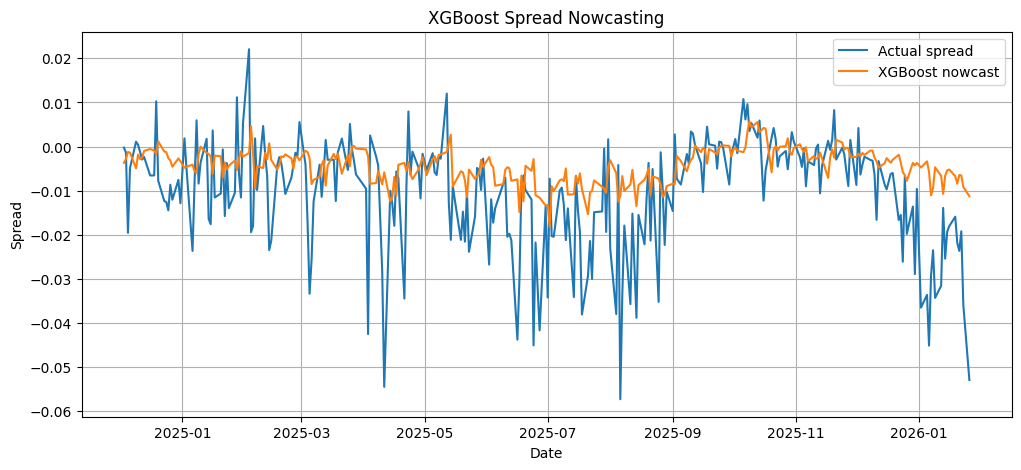

In [75]:
# ==============================
# 8. Plot actual vs predicted spread
# ==============================

plt.figure(figsize=(12,5))

plt.plot(xgb_results["Date"], xgb_results["Actual_spread"], label="Actual spread")
plt.plot(xgb_results["Date"], xgb_results["XGBoost_nowcast"], label="XGBoost nowcast")

plt.title("XGBoost Spread Nowcasting")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.legend()
plt.grid(True)

plt.show()

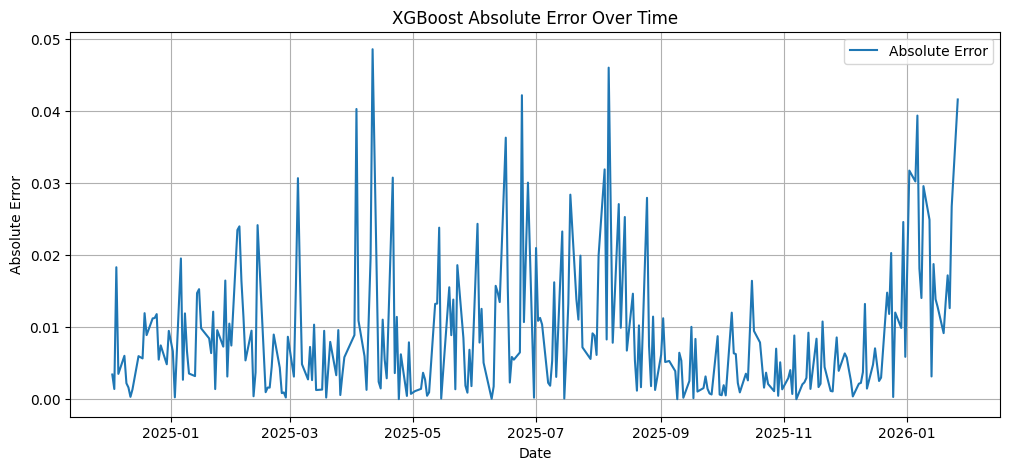

In [76]:
# ==============================
# 9. Plot absolute error spread
# ==============================

plt.figure(figsize=(12,5))

plt.plot(xgb_results["Date"], xgb_results["Abs_Error"], label="Absolute Error")

plt.title("XGBoost Absolute Error Over Time")
plt.xlabel("Date")
plt.ylabel("Absolute Error")
plt.legend()
plt.grid(True)

plt.show()

In [77]:
# Approach 3 : Approach 1 + exponential 
results_table.head()

,Date,Real_spread,Nowcasted_spread,Kalman_sigma,Fixing_USD,r_EURUSD,r_GBPUSD,r_USDJPY,basket_change,Basket_value,Nowcasted_intrinsic,Real_value,Error,Lower_intrinsic_band,Upper_intrinsic_band
0,2024-11-22,0.01110,0.008609,0.019147,3.18745,-0.001164,-0.003136,-0.018189,-0.000377,3.186248,3.194857,3.1804,-0.014457,3.157328,3.232385
1,2024-11-25,-0.01535,-0.011949,0.019035,3.16940,-0.002601,-0.000224,0.010007,0.001454,3.174012,3.162062,3.1721,0.010038,3.124753,3.199372
2,2024-11-26,-0.00700,-0.005473,0.019030,3.17230,-0.006036,-0.006378,-0.000418,0.002388,3.179883,3.174410,3.1624,-0.012010,3.137111,3.211709
3,2024-11-27,-0.01400,-0.011817,0.019030,3.15940,-0.001990,-0.001356,0.019999,0.001762,3.164972,3.153156,3.1583,0.005144,3.115857,3.190454
4,2024-11-28,-0.00260,-0.002713,0.019030,3.16295,-0.001268,-0.010837,0.003136,0.000964,3.165999,3.163286,3.1568,-0.006486,3.125988,3.200585


In [78]:

# ADD EWMA smoothing 


lambda_ewma = 0.5  


results_table["EWMA_spread"] = (
    results_table["Nowcasted_spread"]
    .ewm(alpha=lambda_ewma, adjust=False)
    .mean()
)

In [79]:

# Compute EWMA intrinsic value (parallel version)


results_table["EWMA_intrinsic"] = (
    results_table["Basket_value"] + results_table["EWMA_spread"]
)

In [80]:

# Compute EWMA error


results_table["EWMA_error"] = (
    results_table["Real_value"] - results_table["EWMA_intrinsic"]
)

In [81]:

# Evaluate EWMA model

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_ewma = mean_absolute_error(
    results_table["Real_value"],
    results_table["EWMA_intrinsic"]
)

rmse_ewma = np.sqrt(mean_squared_error(
    results_table["Real_value"],
    results_table["EWMA_intrinsic"]
))

print("EWMA MAE:", mae_ewma)
print("EWMA RMSE:", rmse_ewma)

EWMA MAE: 0.007092012390721888
EWMA RMSE: 0.009630686230687482
